# Exploratory differential expression analysis of CD34+ cells in chronic-phase CML (GSE5550)

Independent exploratory project. Dataset: NCBI GEO **GSE5550** (9 untreated chronic-phase CML patients vs 8 healthy donors, Affymetrix HG-Focus array; Diaz-Blanco et al., *Leukemia* 2007, PMID 17252012).

**Workflow:** GEO2R (limma) differential expression table -> volcano plot -> per-sample expression from the series matrix (GEOparse) -> z-score heatmap of the 25 most significant probes -> gene list for Enrichr.

**Before running:** upload `GSE5550.top.table.tsv` (the full GEO2R results table, in the repository's `data/` folder) to the Colab file panel. Groups used in GEO2R: CML (GSM129059-GSM129067) vs Normal (see `data/sample_metadata.csv`).

Results are hypothesis-generating and not independently validated; see the report for limitations.

## 1. Load the GEO2R differential expression table

In [ ]:
import pandas as pd

data = pd.read_csv("GSE5550.top.table.tsv", sep="\t")

print(data.shape)
data.head()

(8746, 8)


,ID,adj.P.Val,P.Value,t,B,logFC,Gene.symbol,Gene.title
0,210406_s_at,0.000001,2.250000e-10,12.671617,13.83633,0.547606,WTH3DI///RAB6C///RAB6A,"RAB6C-like///RAB6C, member RAS oncogene family..."
1,203284_s_at,0.000001,5.180000e-10,12.031594,13.07189,0.739242,HS2ST1,heparan sulfate 2-O-sulfotransferase 1
2,202123_s_at,0.000001,6.730000e-10,11.835919,12.82998,0.691038,ABL1,"ABL proto-oncogene 1, non-receptor tyrosine ki..."
3,203140_at,0.000001,7.030000e-10,-11.803655,12.78971,-0.749520,BCL6,B-cell CLL/lymphoma 6
4,201666_at,0.000001,9.470000e-10,11.584895,12.51381,0.848893,TIMP1,TIMP metallopeptidase inhibitor 1


## 2. Classify genes and prepare the volcano plot
Up / Down: adjusted p < 0.05 and |log2FC| > 1.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data["neg_log_p"] = -np.log10(data["adj.P.Val"])

def get_category(row):
    if row["adj.P.Val"] < 0.05 and row["logFC"] > 1:
        return "Up"
    elif row["adj.P.Val"] < 0.05 and row["logFC"] < -1:
        return "Down"
    else:
        return "Not Significant"

data["category"] = data.apply(get_category, axis=1)

print(data["category"].value_counts())

category
Not Significant    8692
Up                   28
Down                 26
Name: count, dtype: int64


## 3. Volcano plot

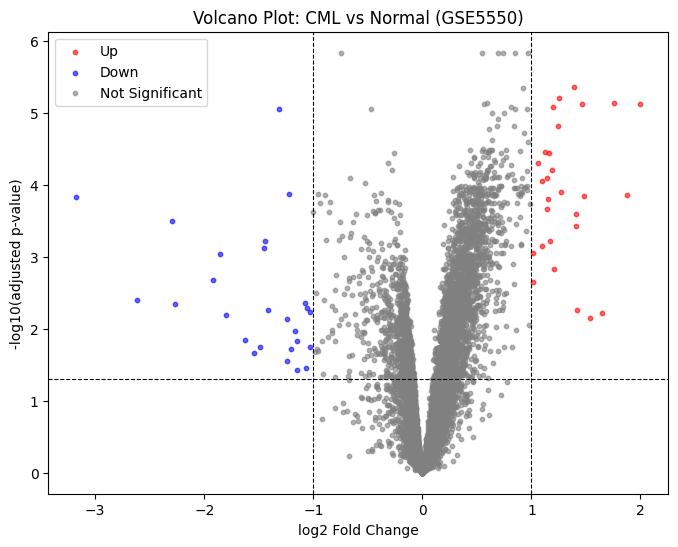

In [ ]:
plt.figure(figsize=(8,6))

colors = {"Up": "red", "Down": "blue", "Not Significant": "grey"}

for cat in colors:
    subset = data[data["category"] == cat]
    plt.scatter(subset["logFC"], subset["neg_log_p"],
                c=colors[cat], label=cat, alpha=0.6, s=10)

plt.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
plt.axvline(1, color="black", linestyle="--", linewidth=0.8)
plt.axvline(-1, color="black", linestyle="--", linewidth=0.8)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot: CML vs Normal (GSE5550)")
plt.legend()
plt.savefig("volcano_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Download per-sample expression values (series matrix) with GEOparse

In [ ]:
!pip install GEOparse

import GEOparse

gse = GEOparse.get_GEO("GSE5550", destdir="./")

26-Sep-2026 06:17:29 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
26-Sep-2026 06:17:29 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE5nnn/GSE5550/soft/GSE5550_family.soft.gz to ./GSE5550_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE5nnn/GSE5550/soft/GSE5550_family.soft.gz to ./GSE5550_family.soft.gz
100%|██████████| 4.06M/4.06M [00:00<00:00, 15.1MB/s]
26-Sep-2026 06:17:29 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
26-Sep-2026 06:17:29 DEBUG downloader - Moving /tmp/tmpu0w4bzti to /content/GSE5550_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpu0w4bzti to /content/GSE5550_family.soft.gz
26-Sep-2026 06:17:29 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE5nnn/GSE5550/soft/GSE5550_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE5nnn/GSE5550/soft/GSE555

In [ ]:
expr = gse.pivot_samples("VALUE")

print(expr.shape)
expr.head()

(8746, 17)


name,GSM129002,GSM129050,GSM129051,GSM129054,GSM129055,GSM129056,GSM129057,GSM129058,GSM129059,GSM129060,GSM129061,GSM129062,GSM129063,GSM129064,GSM129065,GSM129066,GSM129067
ID_REF,,,,,,,,,,,,,,,,,
1007_s_at,5.582173,5.585904,5.511176,5.665409,5.766657,5.575535,5.512595,5.565847,5.278380,5.354513,5.418762,5.374138,5.342171,5.537076,5.505461,5.284712,5.632671
1053_at,5.856617,5.881701,6.023985,6.194872,5.762938,6.036447,5.808436,6.060034,6.305704,6.228412,6.245114,5.851980,6.162474,6.014165,6.043428,6.314617,6.038162
117_at,5.182187,5.121257,5.140318,5.081165,5.380839,5.068688,5.157255,5.281431,5.230250,5.253325,5.186252,5.164271,5.163538,5.176509,5.017861,5.219398,5.108962
121_at,7.213735,7.132903,7.242246,7.147739,6.959519,6.921436,7.102191,7.044233,7.133100,7.094382,7.208049,7.118856,7.192313,7.122765,7.025173,7.135771,7.051735
1255_g_at,4.369466,4.589086,4.460102,4.319511,4.208548,4.324824,4.351936,4.387255,4.351081,4.351081,4.244102,4.322642,4.261210,4.340672,4.304505,4.327452,4.364679


## 5. Expression matrix for the 25 most significant probes (labelled by platform gene annotation)

In [ ]:
top_genes = data.sort_values("adj.P.Val").head(25)

top_ids = top_genes["ID"]

heatmap_data = expr.loc[top_ids]

heatmap_data.index = top_genes.set_index("ID").loc[top_ids, "Gene.symbol"]

heatmap_data.head()

name,GSM129002,GSM129050,GSM129051,GSM129054,GSM129055,GSM129056,GSM129057,GSM129058,GSM129059,GSM129060,GSM129061,GSM129062,GSM129063,GSM129064,GSM129065,GSM129066,GSM129067
Gene.symbol,,,,,,,,,,,,,,,,,
WTH3DI///RAB6C///RAB6A,6.147645,6.097612,6.304149,6.079196,6.245520,6.009772,6.159073,5.993052,6.627415,6.677798,6.777645,6.613672,6.712359,6.620714,6.703526,6.710259,6.650589
HS2ST1,5.706570,5.353102,5.489283,5.263802,5.459053,5.652590,5.442133,5.387806,6.270697,6.253187,6.085514,6.001299,6.365309,6.188574,6.293670,6.217594,6.200965
ABL1,6.636402,6.813302,6.994932,6.635576,6.766196,7.049394,6.808882,6.779298,7.487310,7.554036,7.491172,7.372612,7.464577,7.371881,7.563992,7.650414,7.557830
BCL6,5.260551,5.199569,4.901002,5.135688,5.071246,5.244338,5.366448,5.148000,4.380138,4.411655,4.451096,4.227402,4.454747,4.657727,4.455248,4.467031,4.241970
TIMP1,6.902343,6.944999,7.104425,6.978716,6.898898,6.925746,6.938752,7.018705,8.043898,7.692612,7.624968,7.939458,7.892089,7.427477,7.837392,7.796141,8.062661


## 6. Row-wise z-score heatmap

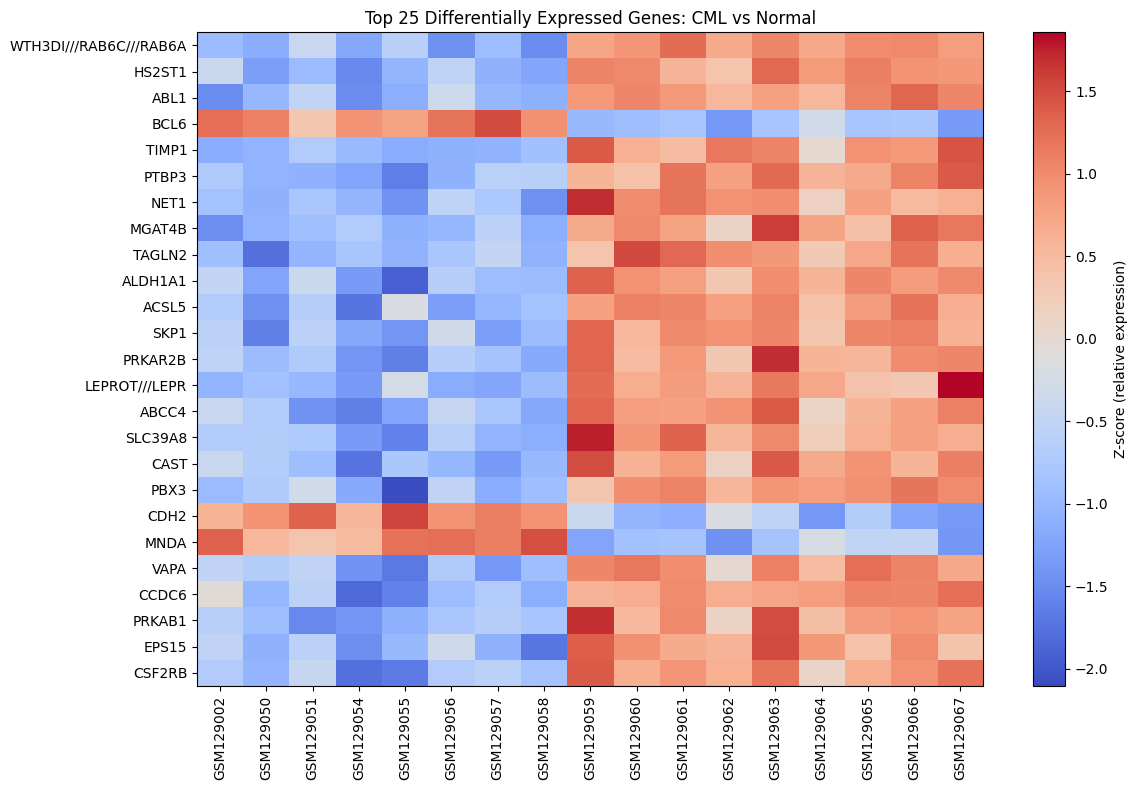

In [ ]:
from scipy.stats import zscore

heatmap_z = heatmap_data.apply(zscore, axis=1, result_type="broadcast")

plt.figure(figsize=(12,8))
plt.imshow(heatmap_z, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Z-score (relative expression)")
plt.yticks(range(len(heatmap_z.index)), heatmap_z.index)
plt.xticks(range(len(heatmap_z.columns)), heatmap_z.columns, rotation=90)
plt.title("Top 25 Probes (by adjusted p-value): CML vs Normal")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Export probe-to-gene mapping and the exact Enrichr input list
Some platform annotations contain several symbols separated by `///` (e.g. `WTH3DI///RAB6C///RAB6A`; WTH3DI is a synonym of the official gene RAB6D). These were split into individual symbols before submission to Enrichr.

In [ ]:
print(", ".join(heatmap_data.index.astype(str)))

WTH3DI///RAB6C///RAB6A, HS2ST1, ABL1, BCL6, TIMP1, PTBP3, NET1, MGAT4B, TAGLN2, ALDH1A1, ACSL5, SKP1, PRKAR2B, LEPROT///LEPR, ABCC4, SLC39A8, CAST, PBX3, CDH2, MNDA, VAPA, CCDC6, PRKAB1, EPS15, CSF2RB


In [ ]:
# Export the 25 most significant probes with their platform gene annotations
# (some annotations contain several symbols separated by "///")
probe_map = top_genes[["ID", "Gene.symbol", "adj.P.Val", "logFC"]]
probe_map.to_csv("probe_to_gene_mapping.csv", index=False)
probe_map


In [ ]:
# Build the exact Enrichr input: split compound "///" annotations into individual symbols
symbols = []
for annotation in top_genes["Gene.symbol"]:
    for s in str(annotation).split("///"):
        if s not in symbols:
            symbols.append(s)

print(len(symbols), "symbols submitted to Enrichr")
with open("enrichr_input_28_symbols.txt", "w") as f:
    f.write("\n".join(symbols))
print(symbols)
